# Ускоренный градиентный метод (метод подобных треугольников)

\begin{equation}
F(x_N) - F(x_\ast) \leqslant  \dfrac{4LR^2}{(N+1)^2}
\end{equation}

_А. В. Гасников, Ю. Е. Нестеров. Универсальный метод для задач стохастической композитной оптимизации. // Журнал вычисл. матем. и матем. физ. Т. 58, № 1 (2018)._

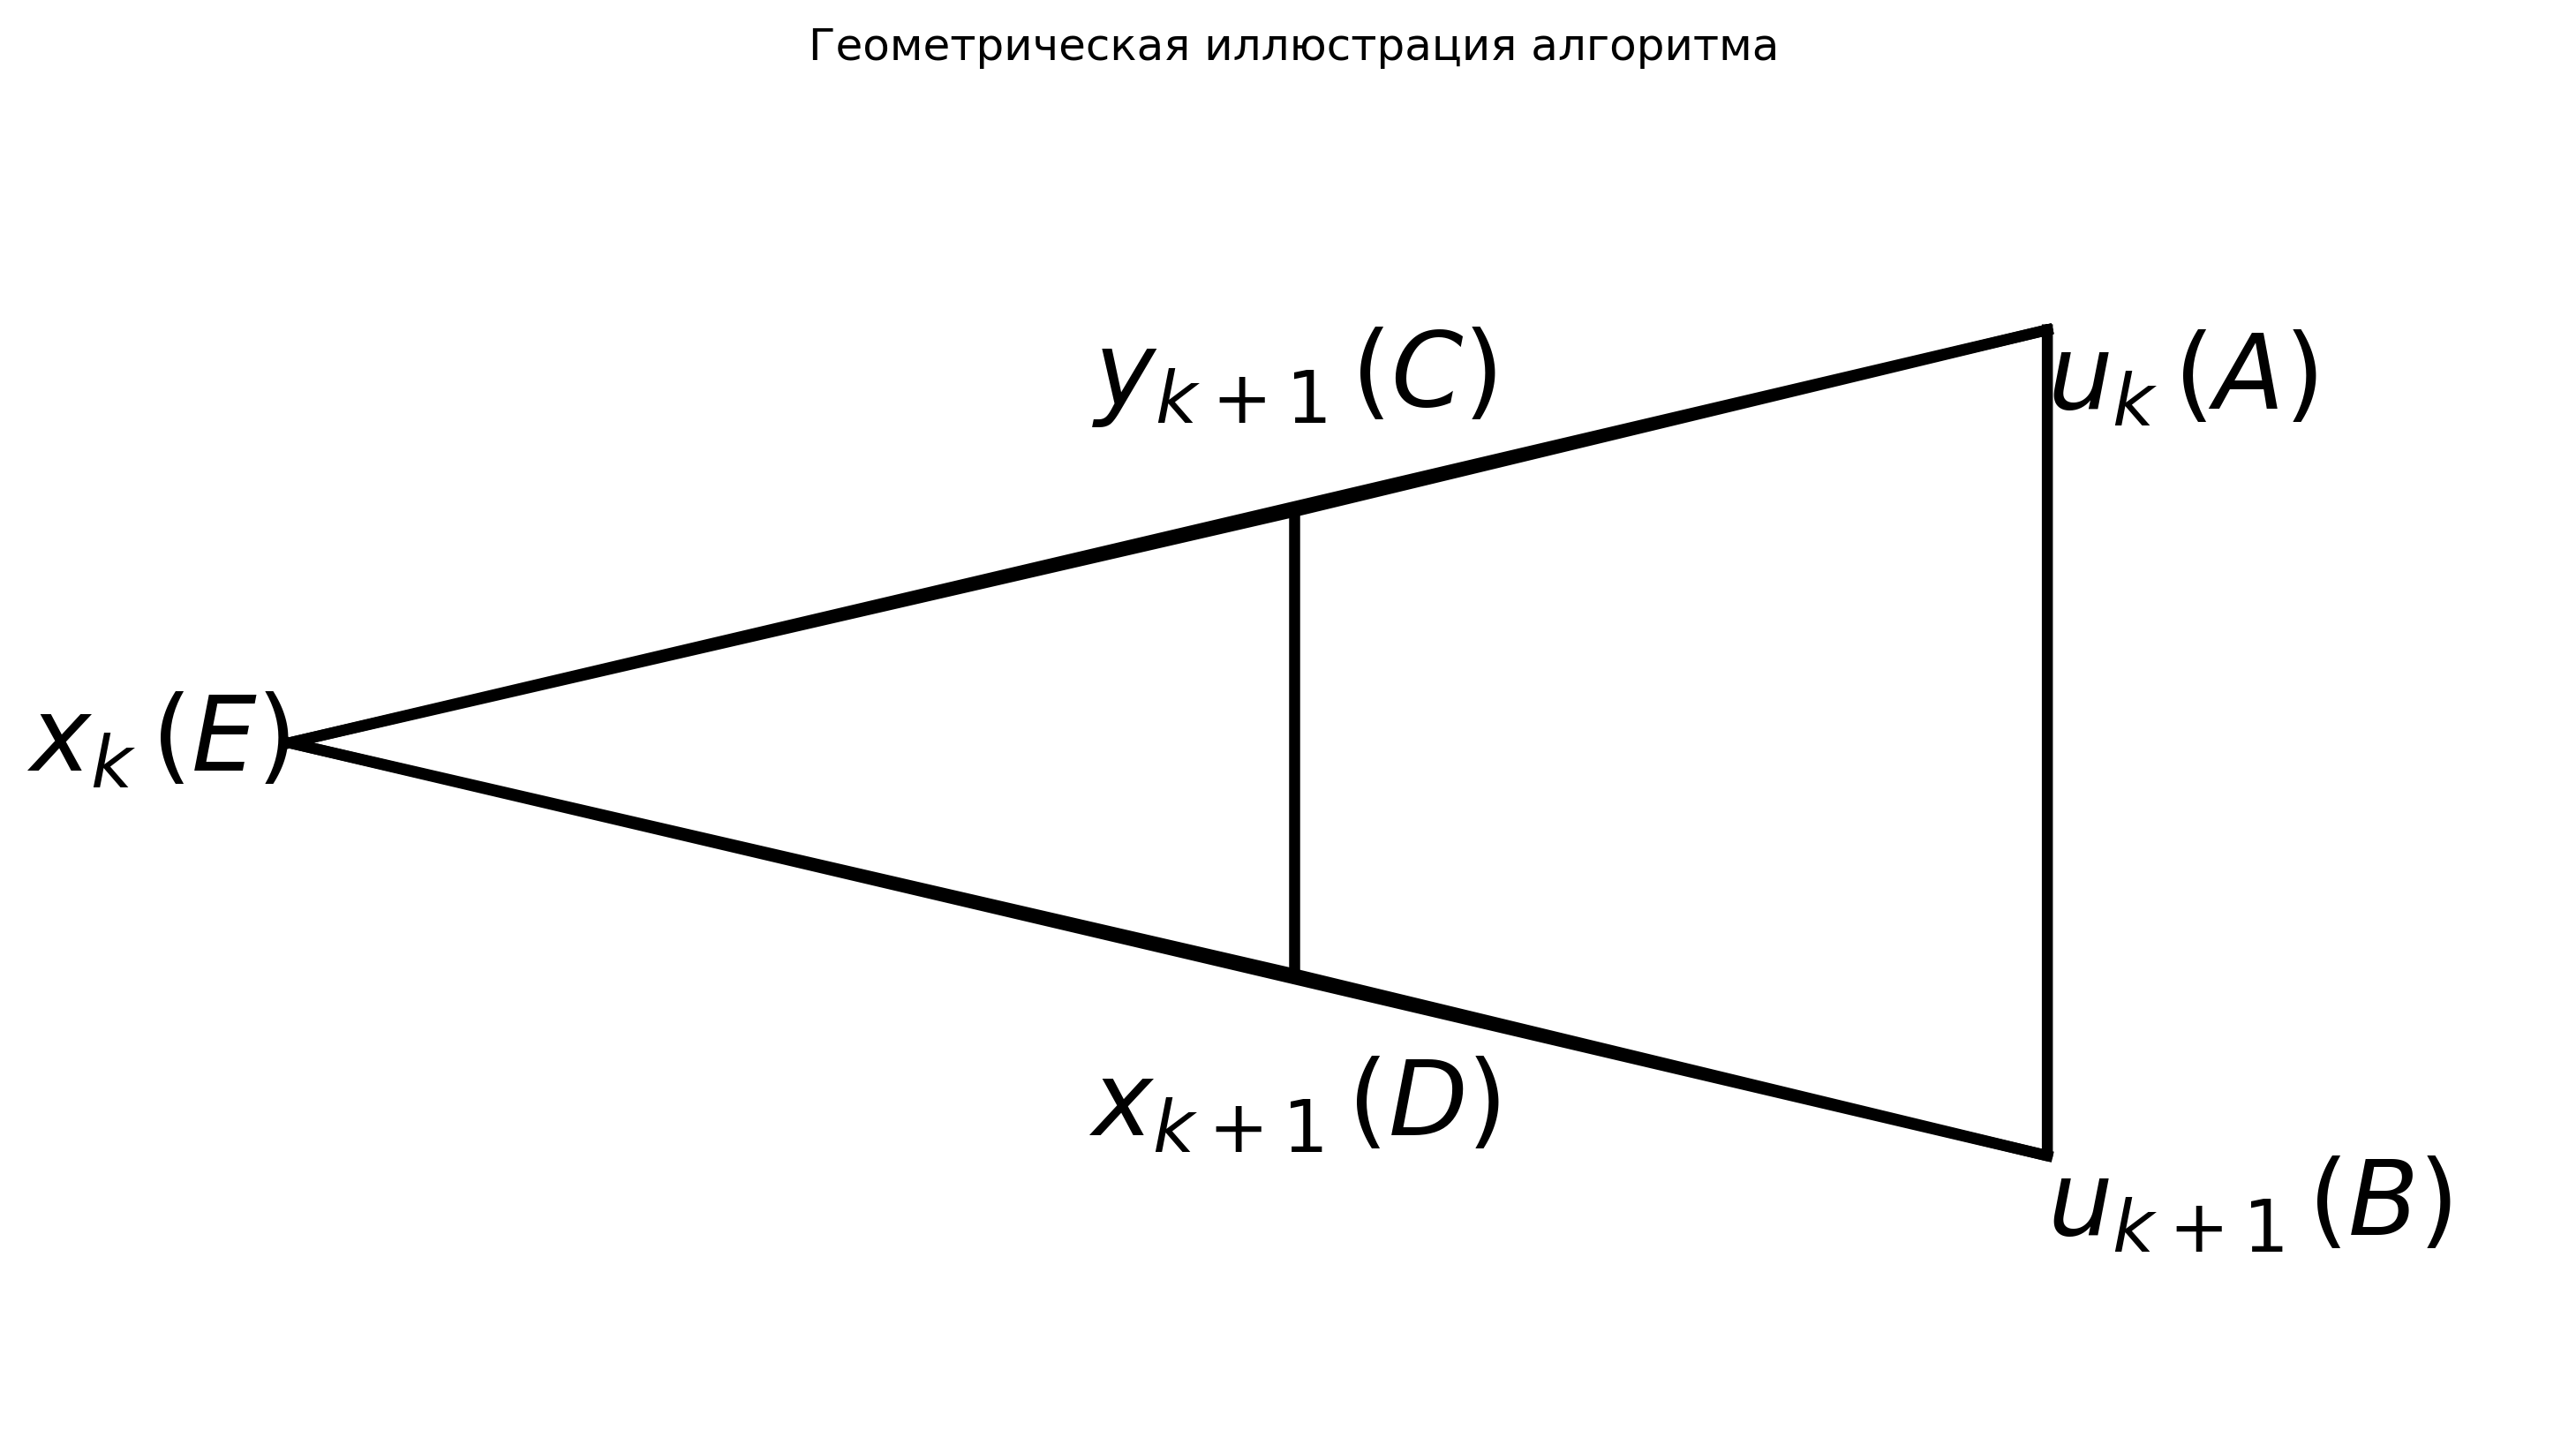

In [1]:
import matplotlib.pyplot as plt

# Координаты точек (примерно по образцу)
A = (8, 6.5)  # u_k (A)
B = (8, 1.5)  # u_{k+1} (B)
E = (1, 4)  # x_k (E)
C = (5, 5.4)  # y_{k+1} (C)
D = (5, 2.6)  # x_{k+1} (D)

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)

# Рисуем многоугольник
ax.plot([A[0], B[0], E[0], A[0]], [A[1], B[1], E[1], A[1]], "k", lw=3)
ax.plot([E[0], C[0], A[0]], [E[1], C[1], A[1]], "k", lw=3)
ax.plot([E[0], D[0], B[0]], [E[1], D[1], B[1]], "k", lw=3)
ax.plot([C[0], D[0]], [C[1], D[1]], "k", lw=3)

ax.text(*A, r"$u_{k}\,(A)$", fontsize=28, va="top", ha="left")
ax.text(*B, r"$u_{k+1}\,(B)$", fontsize=28, va="top", ha="left")
ax.text(C[0], C[1] + 0.5, r"$y_{k+1}\,(C)$", fontsize=28, va="bottom", ha="center")
ax.text(D[0], D[1] - 0.5, r"$x_{k+1}\,(D)$", fontsize=28, va="top", ha="center")
ax.text(*E, r"$x_{k}\,(E)$", fontsize=28, va="center", ha="right")

ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis("off")
plt.title("Геометрическая иллюстрация алгоритма")
plt.tight_layout()
plt.show()

$$
y_{k+1} := \frac{
\alpha_{k+1}u_{k} + A_{k}x_{k}}{A_{k+1}},
$$
$$
u_{k+1} := u_k - \alpha_{k+1}\nabla F(y_{k+1}),
$$
$$
x_{k+1} :=\frac{\alpha_{k+1}u_{k+1} + A_k x_k}{A_{k+1}}
$$



## Общая схема

1. **Инициализация**: $x^0$ – начальная точка, $N$ – количество итераций, константа Липшица градиента целевой функции $L > 0$.

$$
y_0:=x_0,
u_0:=x_0,
\alpha_0=0, 
A_0=\alpha_0
$$

2. **Вычисление:** наибольшего корня квадратного уравнения $L\alpha^2_{k
+1} - \alpha_{k+1} - A_k = 0$,


$$
\alpha_{k+1} := \frac{1+\sqrt{1+4A_kL}}{2L}
$$

$$
Ak+1 := Ak + \alpha_{k+1}.
$$

$$
y_{k+1} := \frac{
\alpha_{k+1}u_{k} + A_{k}x_{k}}{Ak+1},
$$
$$
u_{k+1} := u_k - \alpha_{k+1}\nabla F(y_{k+1}),
$$
$$
xk+1 :=\frac{\alpha_{k+1}u_{k+1} + Akxk}{A_{k+1}}
$$

3. **Повтор** вернуться к шагу 2 до достижения числа итераций $N$

4. **Возврат** вернуть $x_N$.


## Вычислительные эксперименты

In [2]:
from typing import Callable
import numpy as np

In [3]:
def f(x: np.ndarray) -> np.float64:
    """
    Args:
        x: vector to find value of objective at.

    Returns:
        Value of objective at the given |x|.
    """
    r = A @ x - b
    return 0.5 * np.linalg.norm(r) ** 2


def grad(x: np.ndarray) -> np.ndarray:
    """

    Returns:
        Gradient of the objective at the given |x|."""
    r = A @ x - b
    return A.T @ r

In [4]:
def gradient_descent(
    grad: Callable[[np.ndarray], np.ndarray],
    x0: np.ndarray,
    alpha: np.float64,
    tol: np.float64 = 1e-3,
    max_iter: int = 1000,
) -> list[np.ndarray]:
    x = x0.astype(np.float64).copy()
    history: list[np.ndarray] = [x.copy()]

    for _ in range(max_iter):
        grad_x = grad(x)
        if np.linalg.norm(grad_x) < tol:
            break
        x = x - alpha * grad_x
        history.append(x.copy())

    return history

In [5]:
def nesterov_momentum(
    f: Callable[[np.ndarray], float],
    grad_f: Callable[[np.ndarray], np.ndarray],
    x0: np.ndarray,
    L: float,
    max_iter: int = 1000,
) -> list[np.ndarray]:
    x = x0.astype(np.float64).copy()
    u = x.copy()
    A_k = 0.0
    history = [x.copy()]

    for _ in range(max_iter):
        # 1. Compute alpha according to method of similar triangles
        alpha = (1 + np.sqrt(1 + 4 * A_k * L)) / (2 * L)
        A_next = A_k + alpha

        # 2. Interpolation for y
        y = (alpha * u + A_k * x) / A_next

        # 3. Gradient descent step for u
        grad = grad_f(y)
        u_next = u - alpha * grad

        # 4. Interpolation for x
        x_next = (alpha * u_next + A_k * x) / A_next

        # 5. Prepare for next iteration
        x, u, A_k = x_next, u_next, A_next

        history.append(x.copy())

    return history

In [6]:
%%capture --no-display
np.random.seed(2025)

n = 100  # dimension of the problem
A = np.random.randn(n, n).astype(np.float64)
A = A.T @ A + np.random.rand() * np.eye(n)
b = np.random.randn(n).astype(np.float64)
scale = max(np.max(np.abs(A)), np.max(np.abs(b)), 1.0) * 2
A /= scale
b /= scale
x0 = (np.ones(n) * np.random.randint(1, 10)).astype(np.float64)
N = 1000

print(f"Parameters initialized:\n{n=}\n{A=}\n{b=}\n{x0=}\n{N=}")

In [7]:
L = max(np.linalg.eigvals(A)).astype(np.float64)
L

np.float64(1.3187769353033003)

In [8]:
import matplotlib
import seaborn as sns

sns.set_theme()

In [9]:
matplotlib.rc("text", usetex=True)
matplotlib.rc("font", **{"family": "sans-serif"})
params = {"text.latex.preamble": r"\usepackage{amsmath}"}
plt.rcParams.update(params)

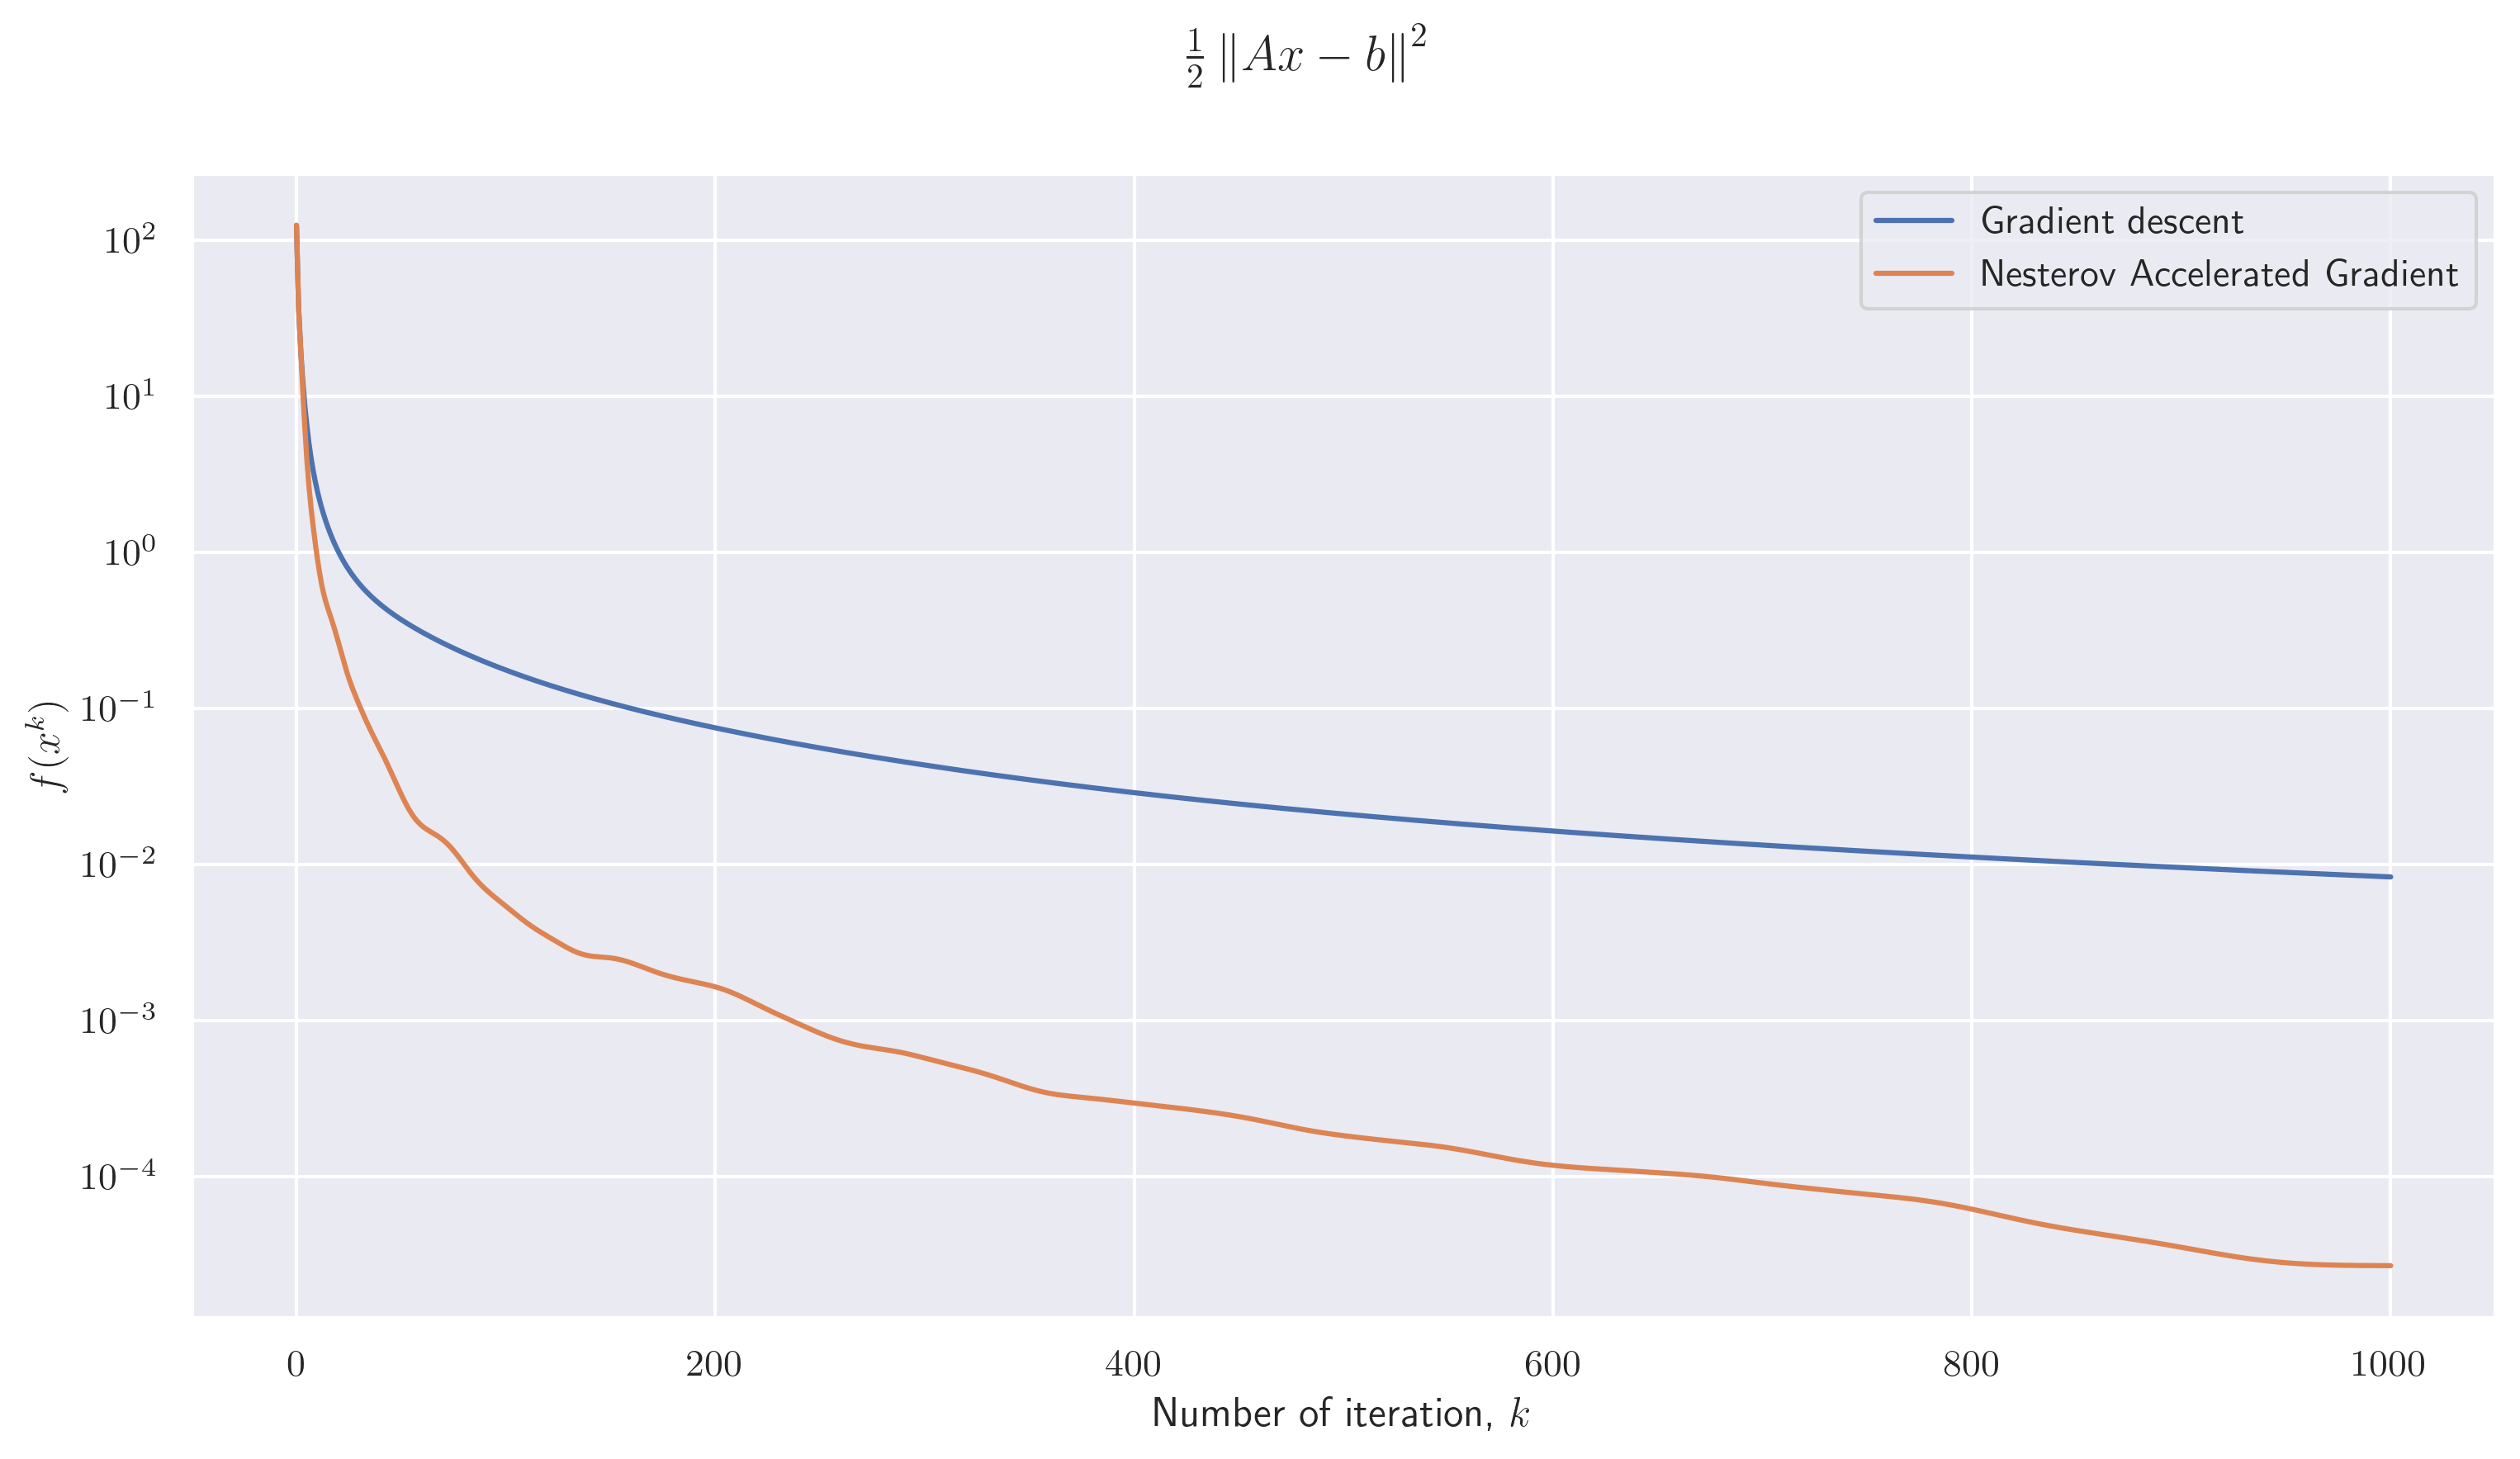

In [10]:
results = [gradient_descent(grad, x0, alpha=1 / L), nesterov_momentum(f, grad, x0, L)]

plt.figure(
    figsize=(
        12,
        6,
    ),
    dpi=300,
)

for i, result in enumerate(results):
    plt.semilogy([i for i in range(len(result))], [f(x) for x in result])

plt.ylabel(r"$f(x^k)$")
plt.xlabel(r"Number of iteration, $k$")

plt.legend(["Gradient descent", "Nesterov Accelerated Gradient"])
plt.suptitle(r"$\frac{1}{2}\left\lVert Ax - b \right\rVert^2$")
plt.show()

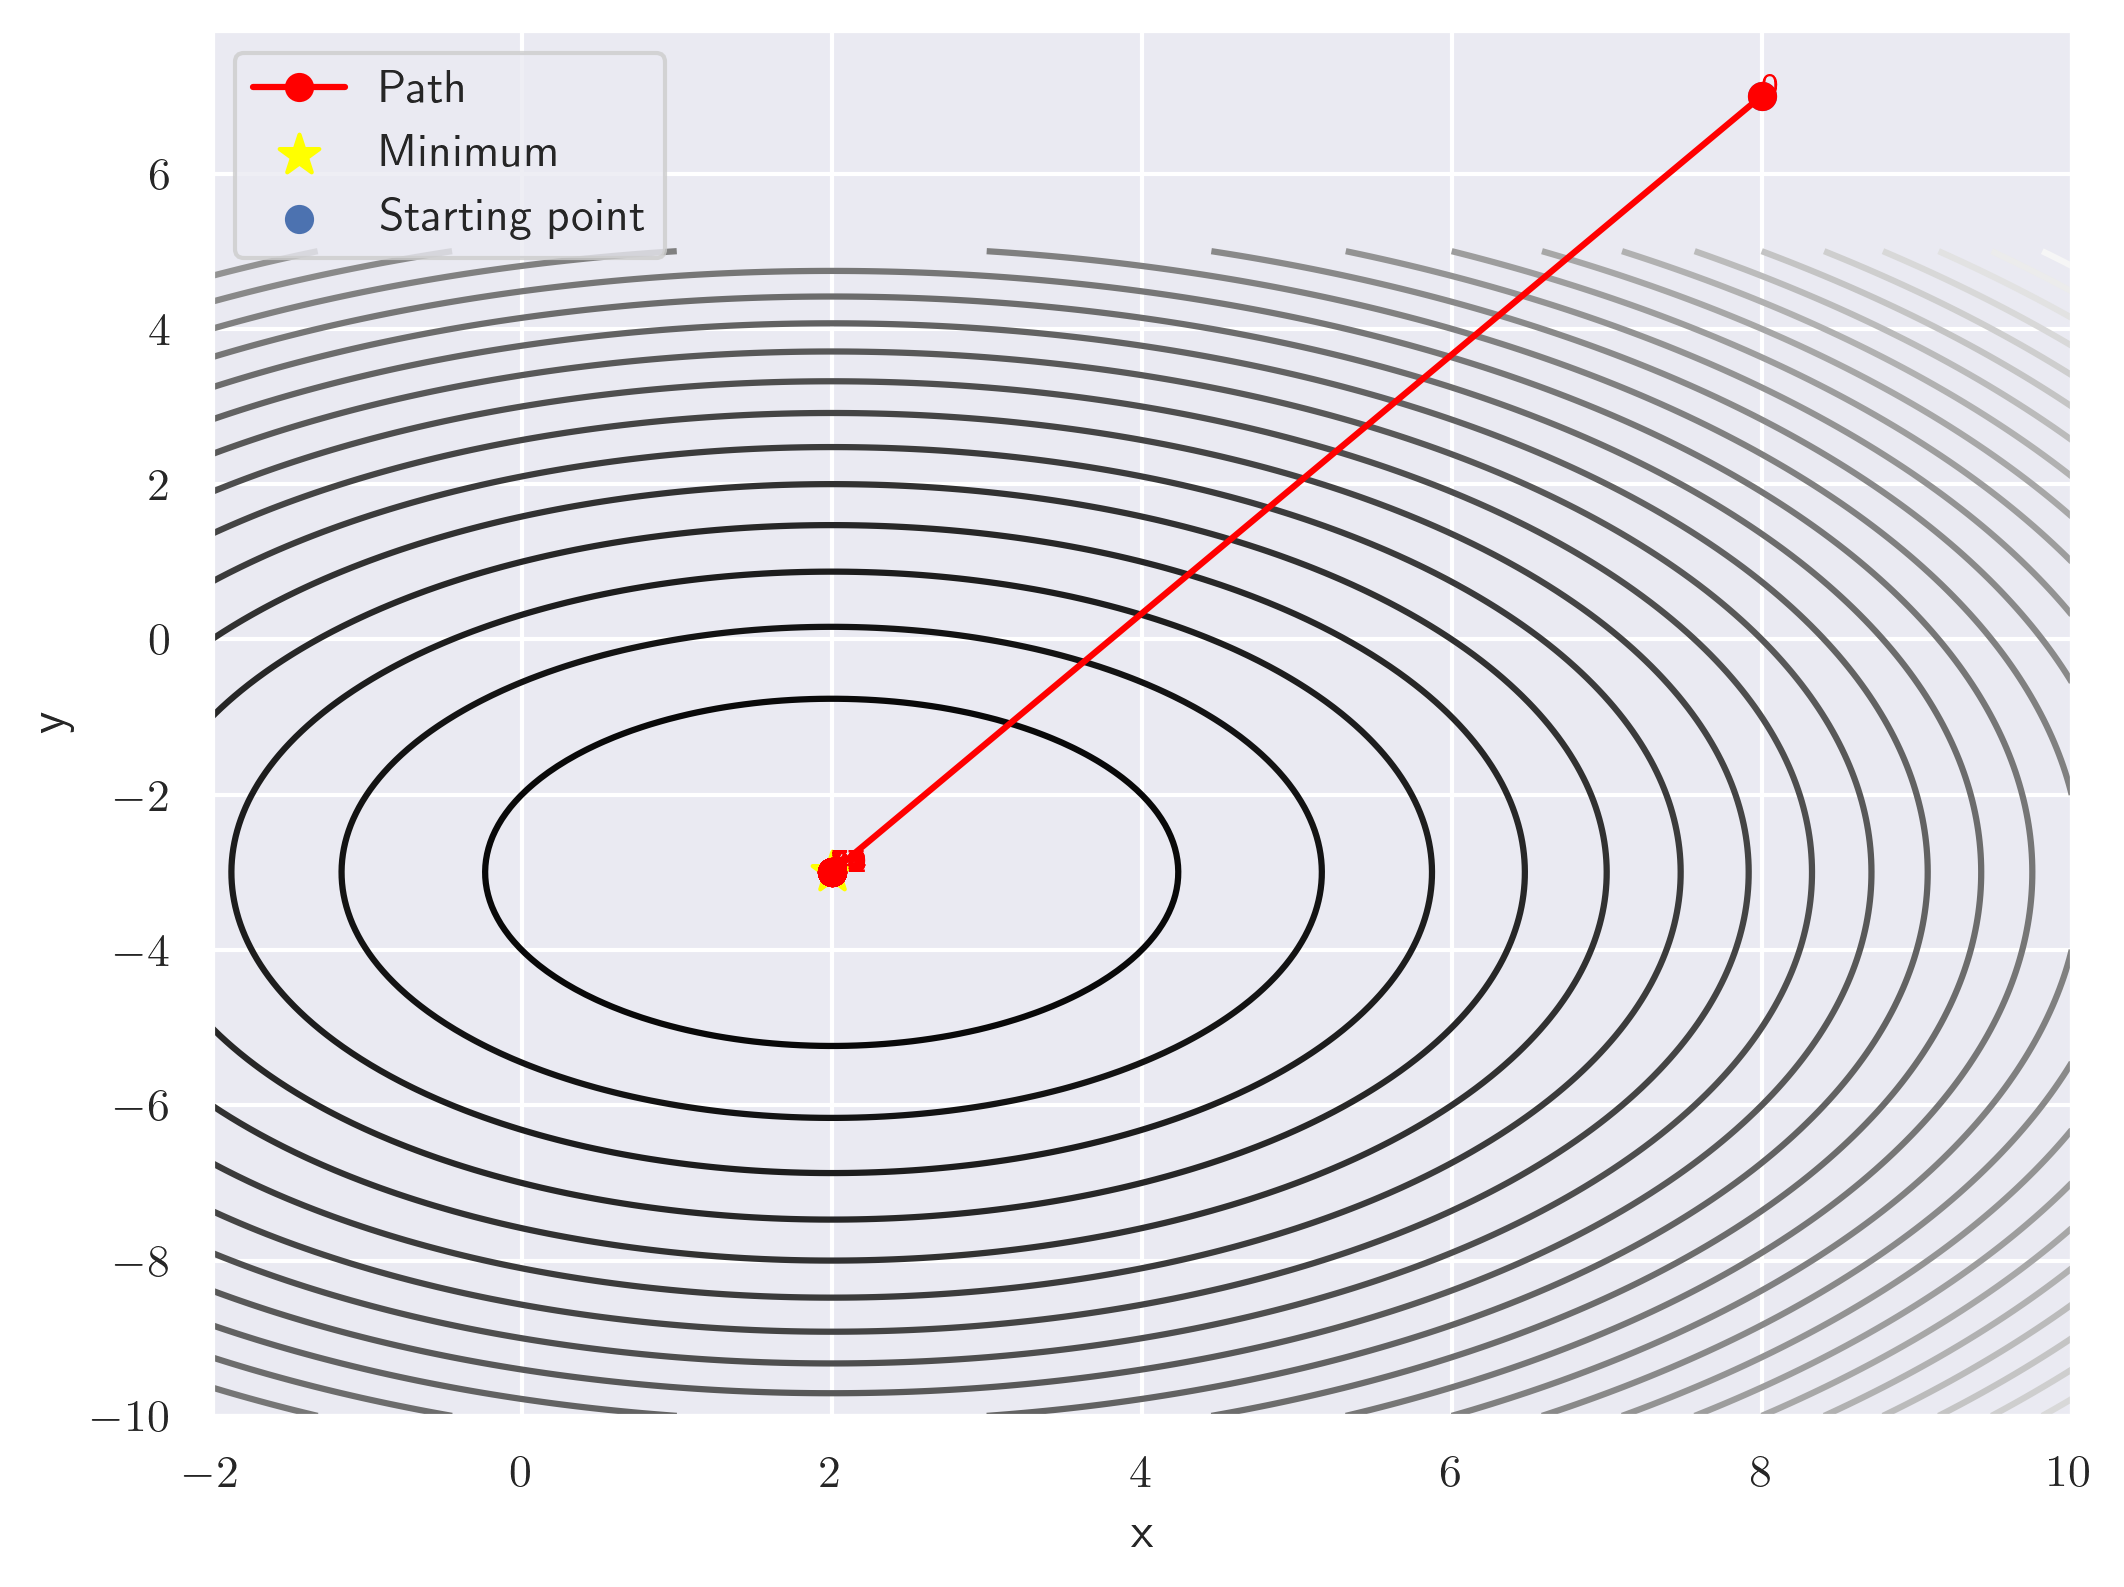

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Функция и ее градиент
def f(xy):
    x, y = xy
    return (x - 2) ** 2 + (y + 3) ** 2


def grad_f(xy):
    x, y = xy
    return np.array([2 * (x - 2), 2 * (y + 3)])


# Параметры
x0 = np.array([8, 7])  # начальная точка
L = 2.0  # шаг градиента
n_iter = 25  # число шагов

# Запуск метода и собираем траекторию
trajectory = np.array(nesterov_momentum(f, grad_f, x0, L, max_iter=n_iter))

# Построение поверхности функции
X, Y = np.meshgrid(np.linspace(-2, 10, 200), np.linspace(-10, 5, 200))
Z = f([X, Y])

plt.figure(figsize=(8, 6), dpi=300)
plt.contour(X, Y, Z, levels=30, cmap="gray")

# Траектория
plt.plot(trajectory[:, 0], trajectory[:, 1], "o-", c="red", label="Path")

# Старт и минимум
plt.scatter([2], [-3], c="yellow", s=100, marker="*", label="Minimum")
plt.scatter(x0[0], x0[1], c="b", label="Starting point")

# Номера итераций
for i, (x, y) in enumerate(trajectory):
    if i % 3 == 0 or i == len(trajectory) - 1:
        plt.annotate(f"{i}", (x, y), color="red", fontsize=8)

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()